In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    accuracy_score,
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.inspection import permutation_importance

import shap

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="notebook")

In [2]:
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTEENN
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False

In [3]:
PROJECT_ROOT = Path("/home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers").resolve()

MODELLING_DIR = PROJECT_ROOT / "notebooks" / "modelling"
FINAL_SELECTION_DIR = MODELLING_DIR / "final_model_selection"
BEST_OVERALL_DIR = FINAL_SELECTION_DIR / "models" / "best_overall"

OUTPUT_DIR = MODELLING_DIR / "xai_analysis" / "08_sensitivity_without_lipid_markers"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = BEST_OVERALL_DIR / "metadata.json"

print("Metadata exists:", METADATA_PATH.exists())
print("Best overall dir:", BEST_OVERALL_DIR)

Metadata exists: True
Best overall dir: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/notebooks/modelling/final_model_selection/models/best_overall


In [4]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

selection = metadata["selection"]
dataset_path = Path(metadata["dataset_path"])
target_column = metadata["target_column"]
random_state = metadata["random_state"]

print("Selected pipeline configuration:")
selection

Selected pipeline configuration:


{'label': 'best_overall',
 'dataset_variant': 'STRICT',
 'config_name': 'config_loo',
 'model_class': 'LinearDiscriminantAnalysis',
 'scaler': 'none',
 'resampling': 'none',
 'pca': 'off',
 'mean_mcc': 0.4862652153958905,
 'std_mcc': 0.0,
 'count': 2,
 'generalization_score': 0.4862652153958905,
 'complexity_score': 0}

In [5]:
df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
print("Dataset path:", dataset_path)
print("Target:", target_column)
df.head()

Dataset shape: (148, 15)
Dataset path: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/data/processed_variants/hcs_strict_complete_case_20260129_114259.csv
Target: MSPH


,row_id,_sheet,LocalID,Age,Weight,Height,BMI_final,Glycemia,SBP_1T,DBP_1T,TC_1T,TG_1T,HDL_1T,LDL_1T,MSPH
0,cohorte_and_000000,cohorte_and,1,33,68.0,169.0,23.8,76.2,101.0,60.0,239,85.1,69.0,153.0,1
1,cohorte_and_000001,cohorte_and,2,37,58.8,162.0,22.4,71.9,101.0,58.0,222,97.0,65.6,137.0,1
2,cohorte_and_000002,cohorte_and,3,30,63.0,160.0,24.6,79.8,113.0,58.0,197,100.0,56.3,120.7,1
3,cohorte_and_000003,cohorte_and,4,26,49.0,154.0,20.7,81.3,98.0,53.0,228,67.0,80.4,134.2,1
4,cohorte_and_000004,cohorte_and,5,25,62.0,163.0,23.3,82.5,106.0,61.0,215,130.0,52.6,136.4,1


In [6]:
SCENARIOS = {
    "full": [
        "Age", "Weight", "Height", "BMI_final", "Glycemia",
        "SBP_1T", "DBP_1T", "TC_1T", "TG_1T", "HDL_1T", "LDL_1T"
    ],
    "no_tc": [
        "Age", "Weight", "Height", "BMI_final", "Glycemia",
        "SBP_1T", "DBP_1T", "TG_1T", "HDL_1T", "LDL_1T"
    ],
    "no_lipid": [
        "Age", "Weight", "Height", "BMI_final", "Glycemia",
        "SBP_1T", "DBP_1T"
    ],
}

for name, feats in SCENARIOS.items():
    print(name, "->", feats)

full -> ['Age', 'Weight', 'Height', 'BMI_final', 'Glycemia', 'SBP_1T', 'DBP_1T', 'TC_1T', 'TG_1T', 'HDL_1T', 'LDL_1T']
no_tc -> ['Age', 'Weight', 'Height', 'BMI_final', 'Glycemia', 'SBP_1T', 'DBP_1T', 'TG_1T', 'HDL_1T', 'LDL_1T']
no_lipid -> ['Age', 'Weight', 'Height', 'BMI_final', 'Glycemia', 'SBP_1T', 'DBP_1T']


In [7]:
all_needed = sorted(set(sum(SCENARIOS.values(), [])) | {target_column})
missing = [c for c in all_needed if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns in dataset: {missing}")

print("All required columns are present.")

All required columns are present.


In [8]:
def make_scaler(name: str):
    name = str(name).lower()
    if name == "none":
        return "passthrough"
    if name == "standard":
        return StandardScaler()
    if name == "robust":
        return RobustScaler()
    if name == "maxabs":
        return MaxAbsScaler()
    raise ValueError(f"Unknown scaler: {name}")


def make_resampler(name: str, random_state: int = 13):
    name = str(name).lower()

    if name == "none":
        return None

    if not IMBLEARN_AVAILABLE:
        raise ImportError("imblearn is required for non-none resampling.")

    if name == "undersample":
        return RandomUnderSampler(random_state=random_state)
    if name == "smote":
        return SMOTE(random_state=random_state)
    if name == "smoteenn":
        return SMOTEENN(random_state=random_state)

    raise ValueError(f"Unknown resampling: {name}")


def make_model(name: str, random_state: int = 13):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=5000, random_state=random_state)
    if name == "LinearDiscriminantAnalysis":
        return LinearDiscriminantAnalysis()
    if name == "QuadraticDiscriminantAnalysis":
        return QuadraticDiscriminantAnalysis()
    if name == "RandomForestClassifier":
        return RandomForestClassifier(
            n_estimators=500,
            random_state=random_state,
            n_jobs=-1,
        )
    if name == "KNeighborsClassifier":
        return KNeighborsClassifier()
    if name in {"SVC", "SVC_linear"}:
        return SVC(kernel="linear", probability=True, random_state=random_state)

    from sklearn.naive_bayes import GaussianNB
    if name == "GaussianNB":
        return GaussianNB()

    raise ValueError(f"Unknown model_class: {name}")


def build_sensitivity_pipeline(selection: dict, feature_columns: list[str], random_state: int = 13):
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", make_scaler(selection["scaler"])),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, feature_columns)
        ],
        remainder="drop",
    )

    steps = [("preprocessor", preprocessor)]

    if str(selection["pca"]).lower() == "on":
        steps.append(("pca", PCA(n_components=0.95, random_state=random_state)))

    model = make_model(selection["model_class"], random_state=random_state)
    resampler = make_resampler(selection["resampling"], random_state=random_state)

    if resampler is not None:
        if not IMBLEARN_AVAILABLE:
            raise ImportError("imblearn is required for resampling pipelines.")
        return ImbPipeline([
            *steps,
            ("resampling", resampler),
            ("model", model),
        ])

    return Pipeline([
        *steps,
        ("model", model),
    ])

In [9]:
def evaluate(y_true, y_prob, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    if len(np.unique(y_true)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        metrics["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics

In [10]:
N_SPLITS = 30

sss = StratifiedShuffleSplit(
    n_splits=N_SPLITS,
    test_size=0.20,
    random_state=random_state
)

results = []

for scenario, features in SCENARIOS.items():
    print(f"Running scenario: {scenario}")

    X = df[features].copy()
    y = df[target_column].astype(int)

    for split_id, (train_idx, test_idx) in enumerate(sss.split(X, y)):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

        model = build_sensitivity_pipeline(
            selection=selection,
            feature_columns=features,
            random_state=random_state,
        )

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            scores = np.asarray(scores, dtype=float)
            if np.allclose(scores.max(), scores.min()):
                y_prob = np.full_like(scores, 0.5, dtype=float)
            else:
                y_prob = (scores - scores.min()) / (scores.max() - scores.min())
        else:
            raise ValueError("Model has neither predict_proba nor decision_function.")

        y_pred = (y_prob >= 0.5).astype(int)

        metrics = evaluate(y_test, y_prob, y_pred)
        metrics.update({
            "scenario": scenario,
            "split": split_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "positive_rate_train": y_train.mean(),
            "positive_rate_test": y_test.mean(),
        })

        results.append(metrics)

results_df = pd.DataFrame(results)
results_df.to_csv(TABLE_DIR / "sensitivity_results.csv", index=False)

print(results_df.shape)
results_df.head()

Running scenario: full
Running scenario: no_tc
Running scenario: no_lipid
(90, 14)


,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,scenario,split,n_train,n_test,positive_rate_train,positive_rate_test
0,0.800000,1.000000,0.333333,0.500000,0.666667,0.509175,0.835979,0.723433,full,0,118,30,0.279661,0.3
1,0.833333,0.833333,0.555556,0.666667,0.753968,0.581914,0.851852,0.749503,full,1,118,30,0.279661,0.3
2,0.800000,0.800000,0.444444,0.571429,0.698413,0.487950,0.899471,0.704938,full,2,118,30,0.279661,0.3
3,0.733333,0.545455,0.666667,0.600000,0.714286,0.407550,0.767196,0.695414,full,3,118,30,0.279661,0.3
4,0.766667,0.666667,0.444444,0.533333,0.674603,0.400066,0.777778,0.599113,full,4,118,30,0.279661,0.3


In [11]:
summary = (
    results_df.groupby("scenario")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_precision=("precision", "mean"),
        std_precision=("precision", "std"),
        mean_recall=("recall", "mean"),
        std_recall=("recall", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        mean_bacc=("balanced_accuracy", "mean"),
        std_bacc=("balanced_accuracy", "std"),
        mean_mcc=("mcc", "mean"),
        std_mcc=("mcc", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_pr_auc=("pr_auc", "mean"),
        std_pr_auc=("pr_auc", "std"),
    )
    .reset_index()
)

summary.to_csv(TABLE_DIR / "sensitivity_summary.csv", index=False)
summary

,scenario,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_bacc,std_bacc,mean_mcc,std_mcc,mean_roc_auc,std_roc_auc,mean_pr_auc,std_pr_auc
0,full,0.770000,0.052046,0.717759,0.173889,0.448148,0.141401,0.529785,0.126176,0.678042,0.065668,0.420847,0.139839,0.796825,0.074147,0.679300,0.078060
1,no_lipid,0.667778,0.046719,0.182778,0.291235,0.059259,0.086231,0.085569,0.123350,0.493915,0.047054,-0.023575,0.156719,0.590653,0.112527,0.435558,0.108413
2,no_tc,0.762222,0.056550,0.693658,0.181921,0.429630,0.142152,0.511855,0.132259,0.667196,0.071624,0.395963,0.156033,0.785714,0.074720,0.641844,0.099579


In [12]:
full_row = summary[summary["scenario"] == "full"].iloc[0]

delta_df = summary.copy()
for metric in ["mean_mcc", "mean_bacc", "mean_f1", "mean_roc_auc", "mean_pr_auc"]:
    delta_df[f"delta_{metric}_vs_full"] = delta_df[metric] - full_row[metric]

delta_df.to_csv(TABLE_DIR / "sensitivity_summary_with_deltas.csv", index=False)
delta_df

,scenario,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_bacc,...,std_mcc,mean_roc_auc,std_roc_auc,mean_pr_auc,std_pr_auc,delta_mean_mcc_vs_full,delta_mean_bacc_vs_full,delta_mean_f1_vs_full,delta_mean_roc_auc_vs_full,delta_mean_pr_auc_vs_full
0,full,0.770000,0.052046,0.717759,0.173889,0.448148,0.141401,0.529785,0.126176,0.678042,...,0.139839,0.796825,0.074147,0.679300,0.078060,0.000000,0.000000,0.000000,0.000000,0.000000
1,no_lipid,0.667778,0.046719,0.182778,0.291235,0.059259,0.086231,0.085569,0.123350,0.493915,...,0.156719,0.590653,0.112527,0.435558,0.108413,-0.444421,-0.184127,-0.444216,-0.206173,-0.243742
2,no_tc,0.762222,0.056550,0.693658,0.181921,0.429630,0.142152,0.511855,0.132259,0.667196,...,0.156033,0.785714,0.074720,0.641844,0.099579,-0.024884,-0.010847,-0.017930,-0.011111,-0.037456


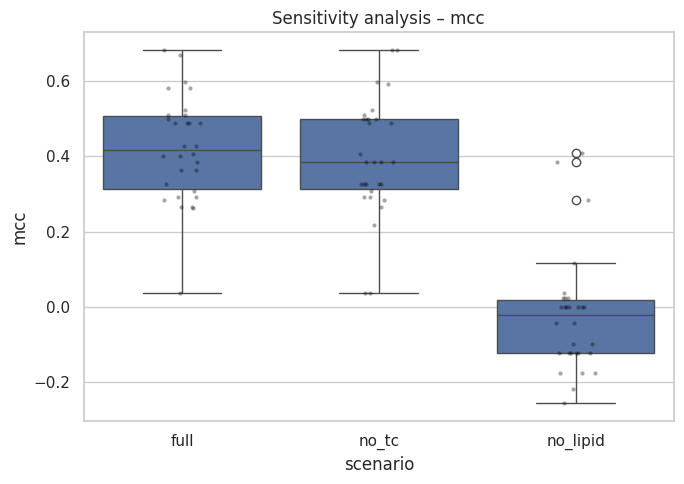

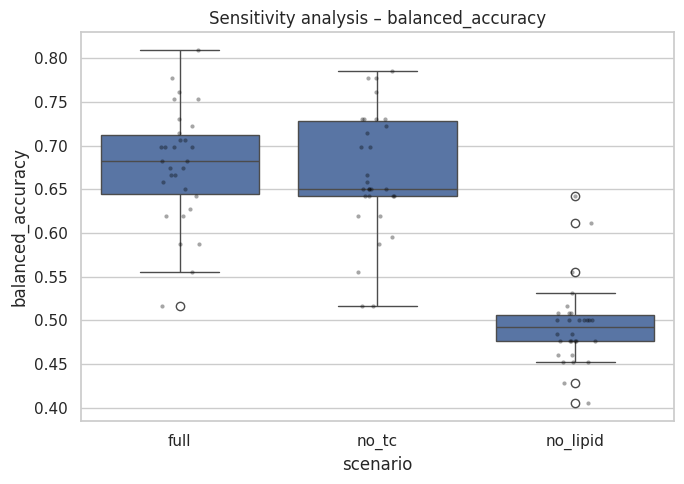

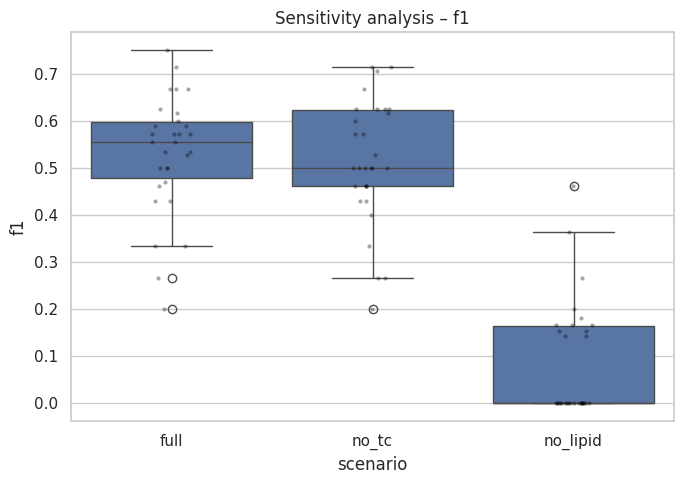

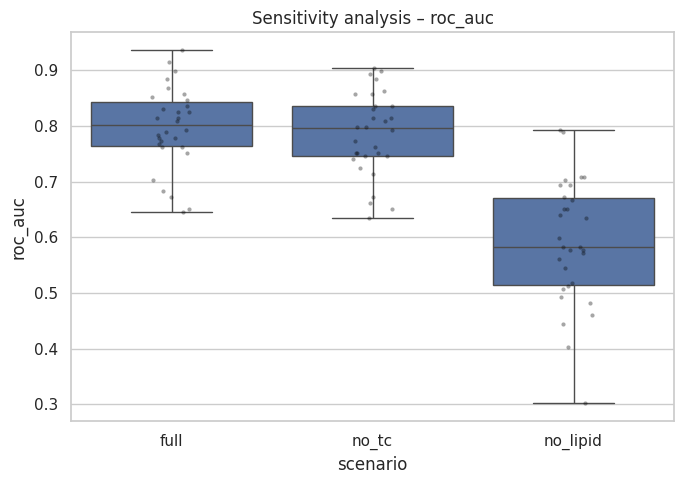

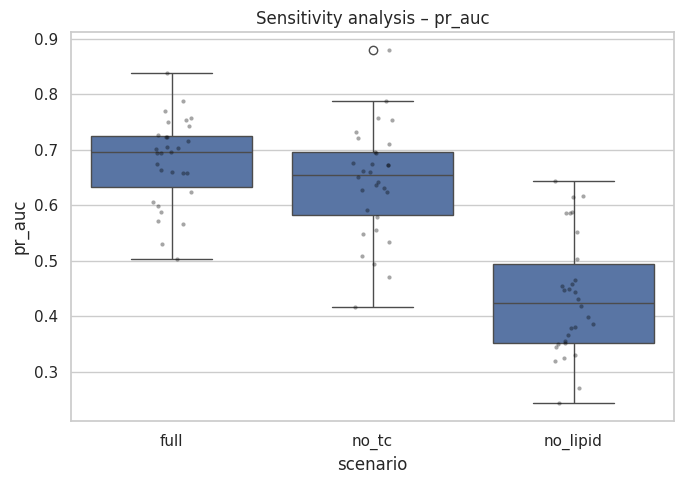

In [13]:
main_metrics = ["mcc", "balanced_accuracy", "f1", "roc_auc", "pr_auc"]

for metric in main_metrics:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=results_df, x="scenario", y=metric)
    sns.stripplot(data=results_df, x="scenario", y=metric, color="black", alpha=0.35, size=3)
    plt.title(f"Sensitivity analysis – {metric}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"sensitivity_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

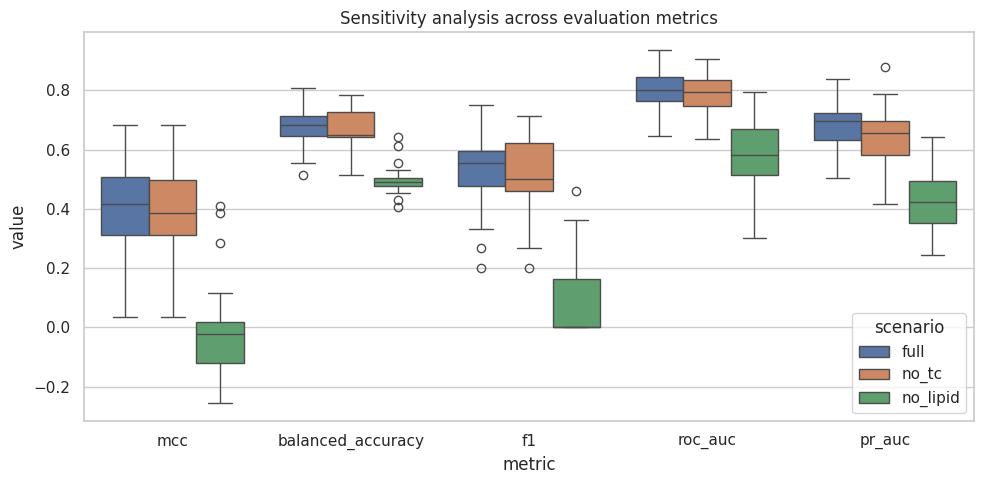

In [14]:
plot_df = results_df.melt(
    id_vars=["scenario", "split"],
    value_vars=["mcc", "balanced_accuracy", "f1", "roc_auc", "pr_auc"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="metric", y="value", hue="scenario")
plt.title("Sensitivity analysis across evaluation metrics")
plt.tight_layout()
plt.savefig(FIG_DIR / "sensitivity_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
fitted_models = {}
scenario_data = {}

for scenario, features in SCENARIOS.items():
    print(f"Fitting final scenario model: {scenario}")

    X = df[features].copy()
    y = df[target_column].astype(int).copy()

    model = build_sensitivity_pipeline(
        selection=selection,
        feature_columns=features,
        random_state=random_state,
    )
    model.fit(X, y)

    fitted_models[scenario] = model
    scenario_data[scenario] = {"X": X, "y": y, "features": features}

Fitting final scenario model: full
Fitting final scenario model: no_tc
Fitting final scenario model: no_lipid


In [16]:
def get_model_input_matrix(fitted_pipeline, X_df):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    X_pre = preprocessor.transform(X_df)

    if "pca" in fitted_pipeline.named_steps:
        X_model = fitted_pipeline.named_steps["pca"].transform(X_pre)
        feature_names = [f"PC{i+1}" for i in range(X_model.shape[1])]
    else:
        X_model = X_pre
        try:
            feature_names = [str(x) for x in preprocessor.get_feature_names_out()]
        except Exception:
            feature_names = list(X_df.columns)

    if hasattr(X_model, "toarray"):
        X_model = X_model.toarray()

    X_model_df = pd.DataFrame(X_model, columns=feature_names, index=X_df.index)
    return X_model_df, feature_names

Running SHAP for: full


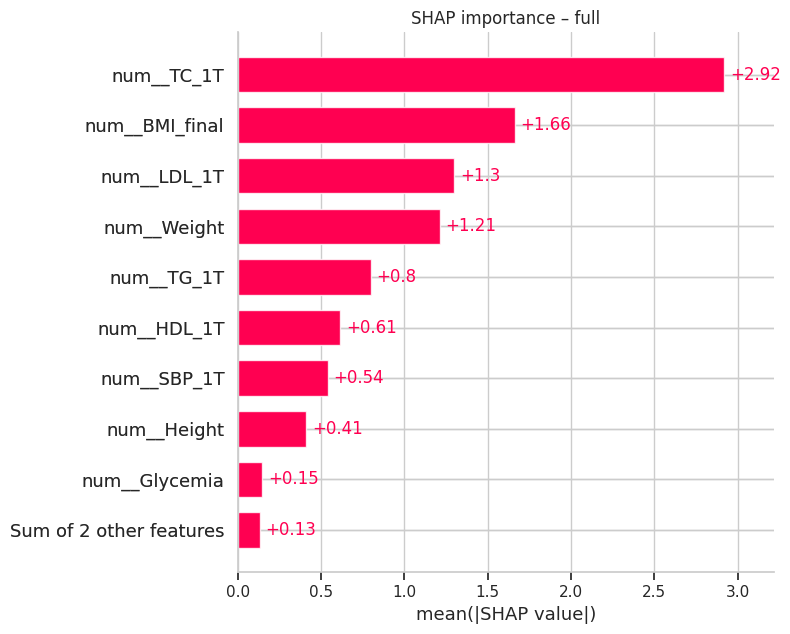

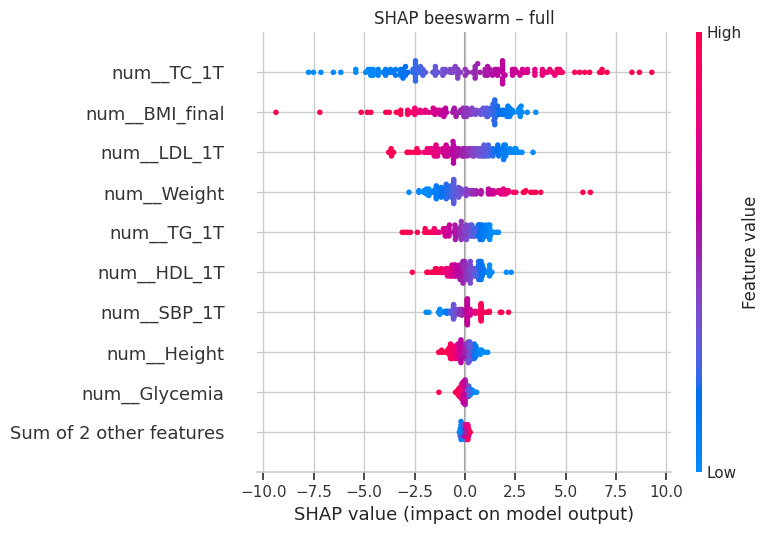

Running SHAP for: no_tc


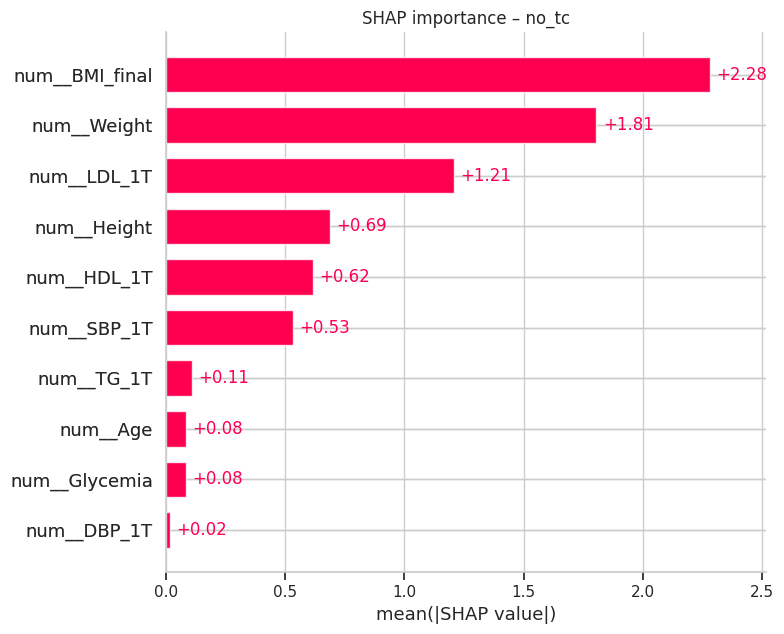

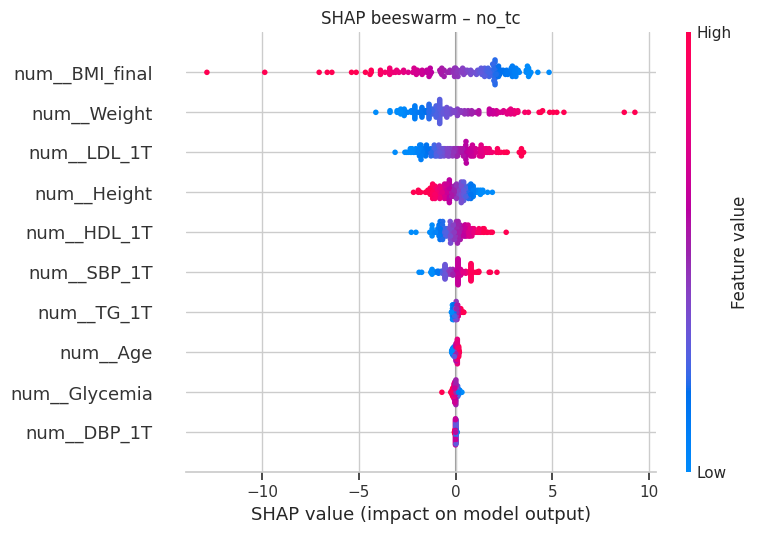

Running SHAP for: no_lipid


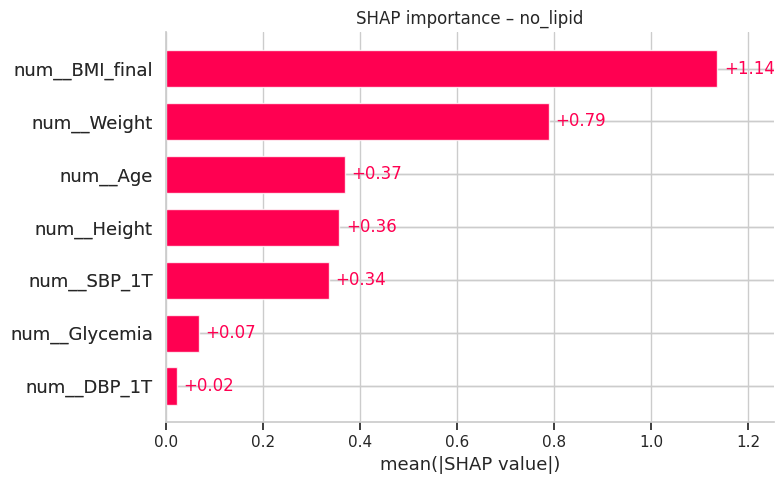

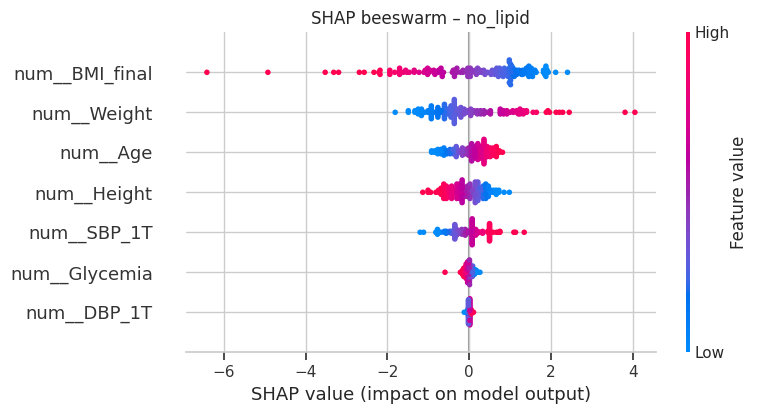

In [17]:
shap_summary_rows = []

for scenario, model in fitted_models.items():
    print(f"Running SHAP for: {scenario}")

    X = scenario_data[scenario]["X"]
    X_model_df, feature_names = get_model_input_matrix(model, X)

    clf = model.named_steps["model"]
    model_name = type(clf).__name__

    if model_name == "RandomForestClassifier":
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer(X_model_df)
    elif model_name in {"LogisticRegression", "LinearDiscriminantAnalysis"}:
        explainer = shap.LinearExplainer(clf, X_model_df)
        shap_values = explainer(X_model_df)
    else:
        background = shap.sample(X_model_df, min(100, len(X_model_df)), random_state=random_state)
        if hasattr(clf, "predict_proba"):
            explainer = shap.KernelExplainer(clf.predict_proba, background)
            shap_raw = explainer.shap_values(X_model_df.iloc[: min(200, len(X_model_df))])
            if isinstance(shap_raw, list):
                shap_matrix = shap_raw[1]
            else:
                shap_matrix = shap_raw
            X_sub = X_model_df.iloc[: min(200, len(X_model_df))].copy()
            shap_values = shap.Explanation(
                values=shap_matrix,
                data=X_sub.values,
                feature_names=list(X_sub.columns),
            )
        else:
            continue

    plt.figure()
    shap.plots.bar(shap_values, show=False)
    plt.title(f"SHAP importance – {scenario}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"shap_bar_{scenario}.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure()
    shap.plots.beeswarm(shap_values, show=False)
    plt.title(f"SHAP beeswarm – {scenario}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"shap_beeswarm_{scenario}.png", dpi=300, bbox_inches="tight")
    plt.show()

    mean_abs = np.abs(shap_values.values).mean(axis=0)
    shap_imp = pd.DataFrame({
        "scenario": scenario,
        "feature": feature_names,
        "mean_abs_shap": mean_abs,
    }).sort_values("mean_abs_shap", ascending=False)

    shap_imp.to_csv(TABLE_DIR / f"shap_importance_{scenario}.csv", index=False)
    shap_summary_rows.append(shap_imp)

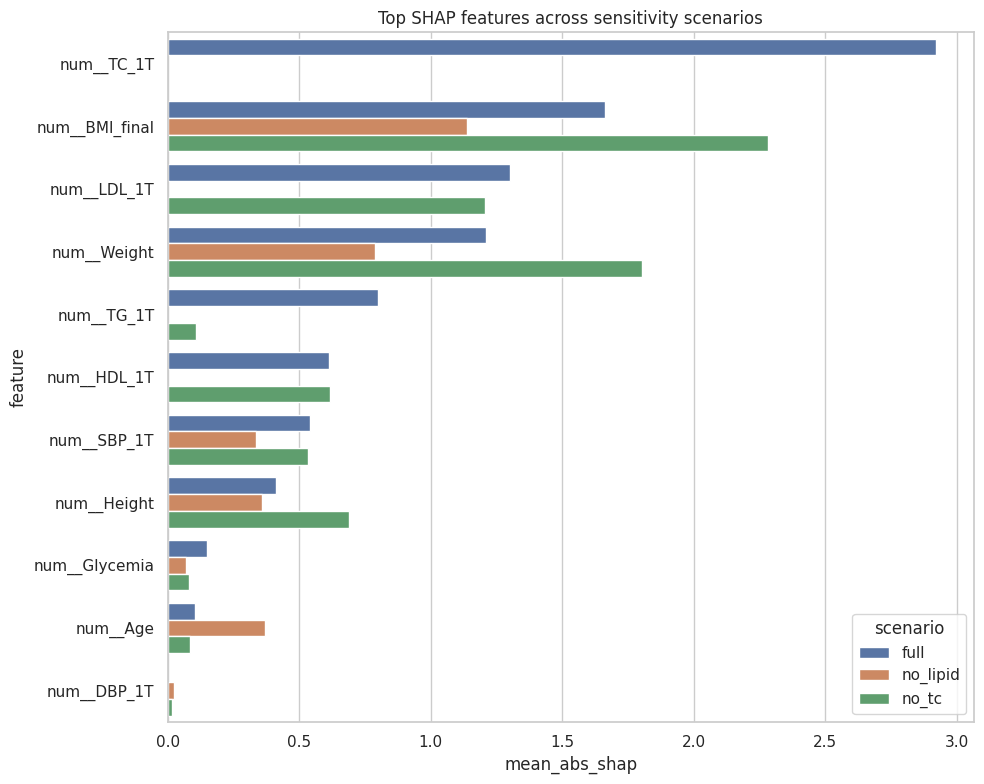

In [18]:
shap_summary_df = pd.concat(shap_summary_rows, ignore_index=True)
shap_summary_df.to_csv(TABLE_DIR / "shap_importance_all_scenarios.csv", index=False)

top_shap = (
    shap_summary_df.sort_values(["scenario", "mean_abs_shap"], ascending=[True, False])
    .groupby("scenario")
    .head(10)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_shap, x="mean_abs_shap", y="feature", hue="scenario")
plt.title("Top SHAP features across sensitivity scenarios")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_importance_across_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

Running permutation importance for: full


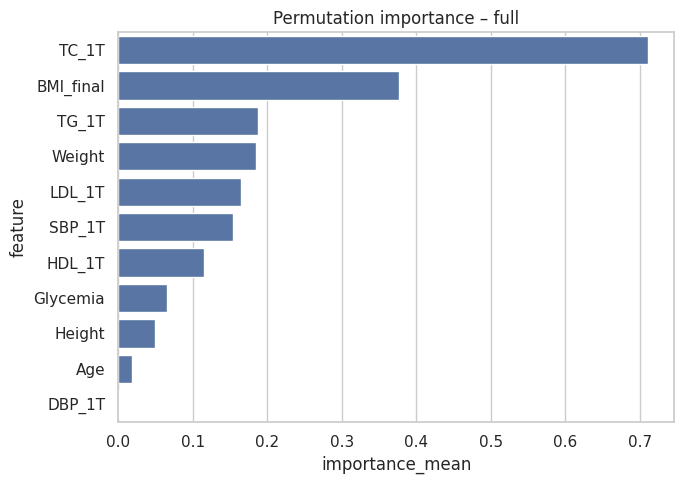

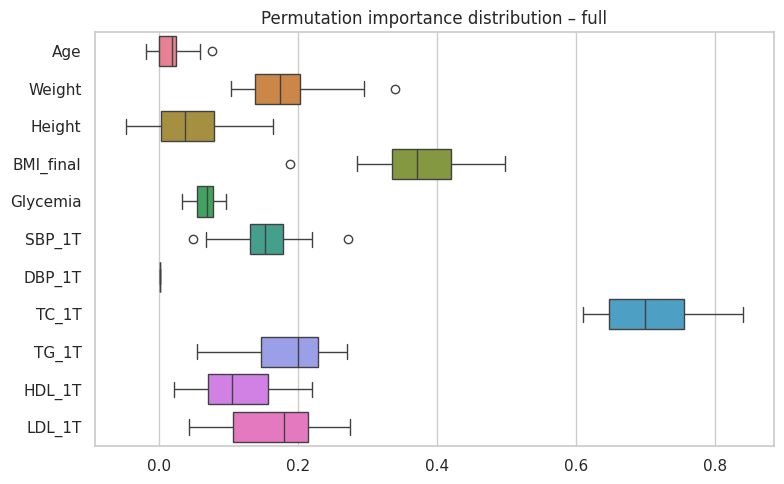

Running permutation importance for: no_tc


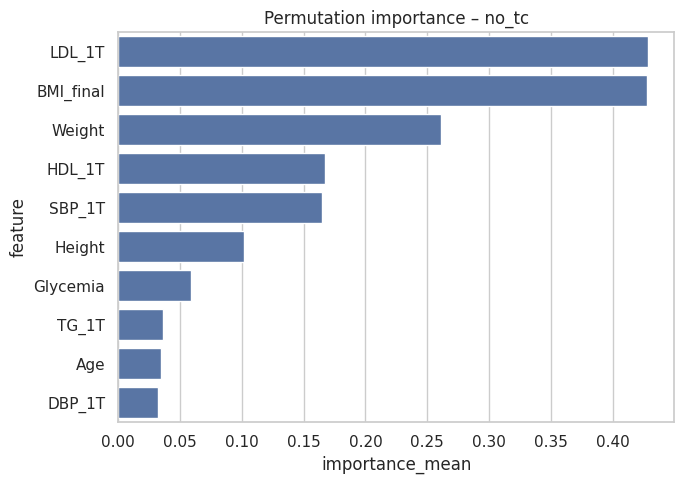

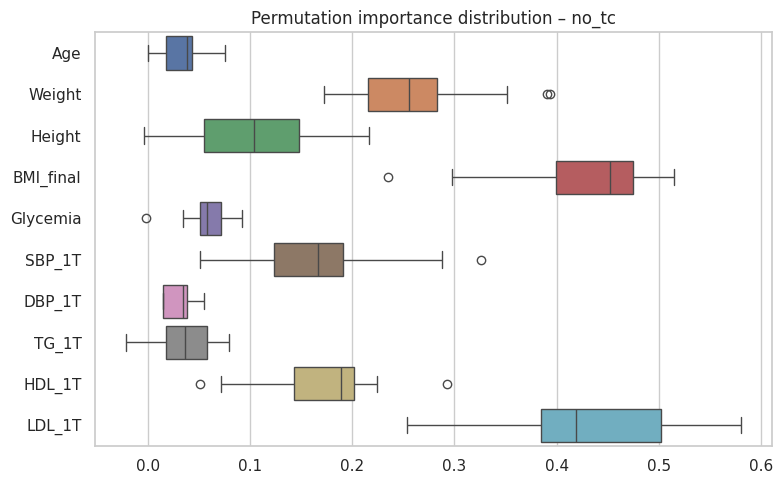

Running permutation importance for: no_lipid


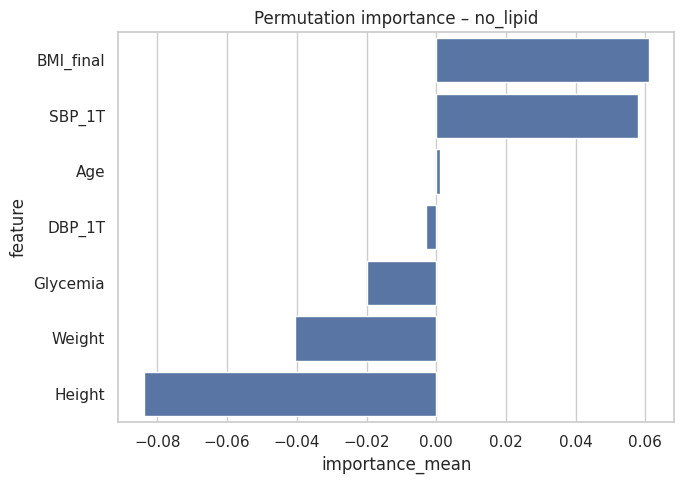

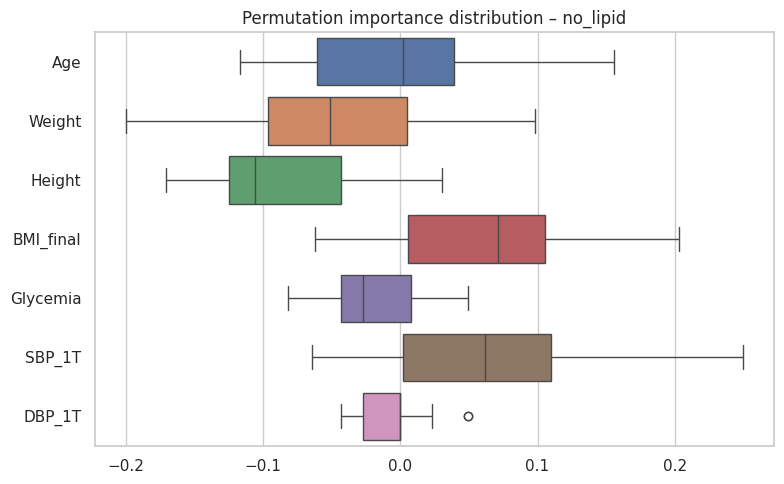

In [19]:
perm_rows = []

for scenario, model in fitted_models.items():
    print(f"Running permutation importance for: {scenario}")

    X = scenario_data[scenario]["X"]
    y = scenario_data[scenario]["y"]
    features = scenario_data[scenario]["features"]

    result = permutation_importance(
        model,
        X,
        y,
        n_repeats=20,
        random_state=random_state,
        scoring="matthews_corrcoef",
        n_jobs=-1,
    )

    imp = pd.DataFrame({
        "scenario": scenario,
        "feature": features,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }).sort_values("importance_mean", ascending=False)

    imp.to_csv(TABLE_DIR / f"perm_importance_{scenario}.csv", index=False)
    perm_rows.append(imp)

    plt.figure(figsize=(7, 5))
    sns.barplot(data=imp, x="importance_mean", y="feature")
    plt.title(f"Permutation importance – {scenario}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"perm_importance_{scenario}.png", dpi=300, bbox_inches="tight")
    plt.show()

    perm_dist_df = pd.DataFrame(result.importances.T, columns=features)
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=perm_dist_df, orient="h")
    plt.title(f"Permutation importance distribution – {scenario}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"perm_importance_distribution_{scenario}.png", dpi=300, bbox_inches="tight")
    plt.show()

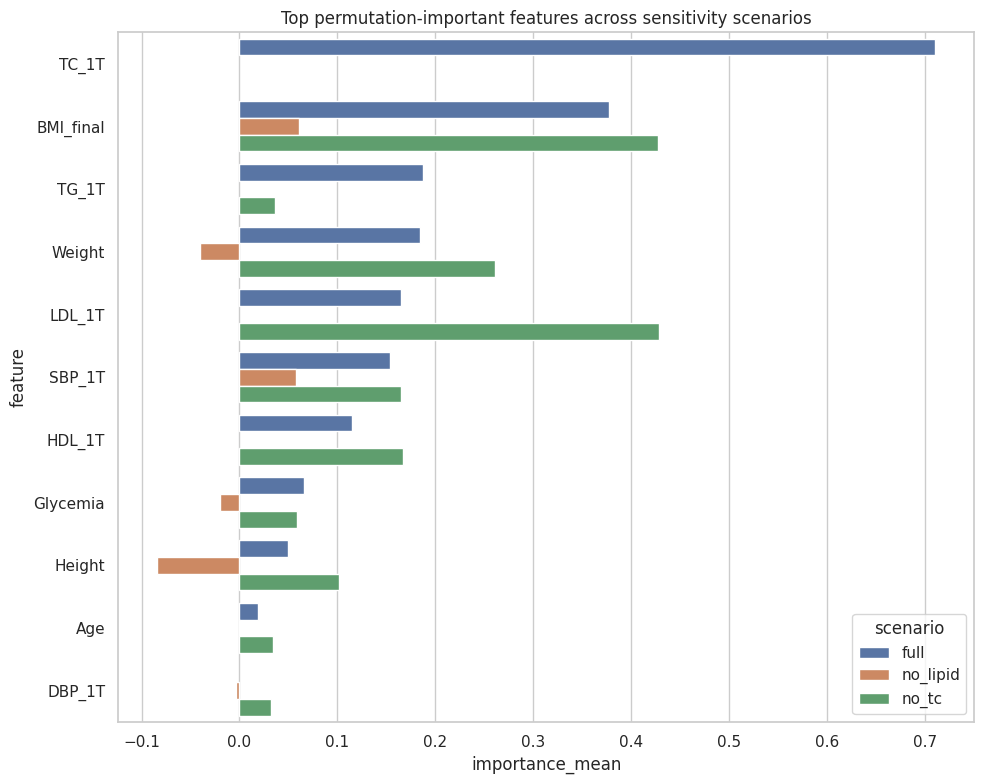

In [20]:
perm_df = pd.concat(perm_rows, ignore_index=True)
perm_df.to_csv(TABLE_DIR / "perm_importance_all_scenarios.csv", index=False)

top_perm = (
    perm_df.sort_values(["scenario", "importance_mean"], ascending=[True, False])
    .groupby("scenario")
    .head(10)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_perm, x="importance_mean", y="feature", hue="scenario")
plt.title("Top permutation-important features across sensitivity scenarios")
plt.tight_layout()
plt.savefig(FIG_DIR / "perm_importance_across_scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
report_table = summary.copy()

for metric in ["accuracy", "precision", "recall", "f1", "bacc", "mcc", "roc_auc", "pr_auc"]:
    mean_col = f"mean_{metric}"
    std_col = f"std_{metric}"
    if mean_col in report_table.columns and std_col in report_table.columns:
        report_table[f"{metric}_report"] = (
            report_table[mean_col].round(3).astype(str)
            + " ± "
            + report_table[std_col].round(3).astype(str)
        )

report_table.to_csv(TABLE_DIR / "sensitivity_report_table.csv", index=False)
report_table

,scenario,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,mean_bacc,...,mean_pr_auc,std_pr_auc,accuracy_report,precision_report,recall_report,f1_report,bacc_report,mcc_report,roc_auc_report,pr_auc_report
0,full,0.770000,0.052046,0.717759,0.173889,0.448148,0.141401,0.529785,0.126176,0.678042,...,0.679300,0.078060,0.77 ± 0.052,0.718 ± 0.174,0.448 ± 0.141,0.53 ± 0.126,0.678 ± 0.066,0.421 ± 0.14,0.797 ± 0.074,0.679 ± 0.078
1,no_lipid,0.667778,0.046719,0.182778,0.291235,0.059259,0.086231,0.085569,0.123350,0.493915,...,0.435558,0.108413,0.668 ± 0.047,0.183 ± 0.291,0.059 ± 0.086,0.086 ± 0.123,0.494 ± 0.047,-0.024 ± 0.157,0.591 ± 0.113,0.436 ± 0.108
2,no_tc,0.762222,0.056550,0.693658,0.181921,0.429630,0.142152,0.511855,0.132259,0.667196,...,0.641844,0.099579,0.762 ± 0.057,0.694 ± 0.182,0.43 ± 0.142,0.512 ± 0.132,0.667 ± 0.072,0.396 ± 0.156,0.786 ± 0.075,0.642 ± 0.1


In [22]:
display(delta_df[[
    "scenario",
    "mean_mcc", "delta_mean_mcc_vs_full",
    "mean_bacc", "delta_mean_bacc_vs_full",
    "mean_f1", "delta_mean_f1_vs_full",
    "mean_roc_auc", "delta_mean_roc_auc_vs_full",
    "mean_pr_auc", "delta_mean_pr_auc_vs_full",
]].sort_values("scenario"))

,scenario,mean_mcc,delta_mean_mcc_vs_full,mean_bacc,delta_mean_bacc_vs_full,mean_f1,delta_mean_f1_vs_full,mean_roc_auc,delta_mean_roc_auc_vs_full,mean_pr_auc,delta_mean_pr_auc_vs_full
0,full,0.420847,0.000000,0.678042,0.000000,0.529785,0.000000,0.796825,0.000000,0.679300,0.000000
1,no_lipid,-0.023575,-0.444421,0.493915,-0.184127,0.085569,-0.444216,0.590653,-0.206173,0.435558,-0.243742
2,no_tc,0.395963,-0.024884,0.667196,-0.010847,0.511855,-0.017930,0.785714,-0.011111,0.641844,-0.037456
